# Principal Component Analysis: A Comprehensive Guide

## 1. Introduction

This notebook covers the step-by-step implementation of **Principal Component Analysis** in Python.

### Concept Overview
An unsupervised linear transformation that projects high-dimensional features onto lower-dimensional orthogonal principal components representing maximum variance.

### Mathematical Formula
The core mathematical relationship or objective is defined as:
$$
\mathbf{\Sigma} \mathbf{v} = \lambda \mathbf{v} \quad \text{where } \mathbf{\Sigma} \text{ is the Covariance Matrix, } \mathbf{v} \text{ are Eigenvectors, and } \lambda \text{ are Eigenvalues}
$$

### Real-World Analogy
**Analogy:** Taking a 2D photograph of a 3D statue from the angle that captures the most detail.

### Worked Example
**Worked Example:** Reducing 6-dimensional wine features to 2 principal components. PCA finds the first direction PC1 that captures 65% of data spread, and PC2 perpendicular to PC1 capturing 20% of spread. 85% variance is kept.

## 2. Import Libraries

We import the standard data science and machine learning libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 3. Create Synthetic Dataset

We generate a realistic synthetic dataset to demonstrate the model's behavior and save it locally.

In [2]:
# Programmatic generation of high-dim wine features
from sklearn.datasets import make_blobs
np.random.seed(42)
# Generate 6 features with correlations representing wine attributes
X_raw, _ = make_blobs(n_samples=250, n_features=6, centers=3, cluster_std=1.5, random_state=42)
df = pd.DataFrame(X_raw, columns=['Alcohol', 'MalicAcid', 'Ash', 'Alcalinity', 'Magnesium', 'TotalPhenols'])
# Add correlation relationships
df['Alcohol'] = df['Alcohol'] * 0.4 + 13.0
df['MalicAcid'] = np.abs(df['MalicAcid'] * 0.5 + 2.0)
df['Alcalinity'] = df['Alcalinity'] * 2.0 + 19.0
df.to_csv('dataset.csv', index=False)

## 4. Load & Inspect Dataset

We load the dataset using pandas to inspect the shape, variables, and summary statistics.

In [3]:
df = pd.read_csv('dataset.csv')
print('Dataset Shape:', df.shape)
df.info()
print(df.describe())

Dataset Shape: (250, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Alcohol       250 non-null    float64
 1   MalicAcid     250 non-null    float64
 2   Ash           250 non-null    float64
 3   Alcalinity    250 non-null    float64
 4   Magnesium     250 non-null    float64
 5   TotalPhenols  250 non-null    float64
dtypes: float64(6)
memory usage: 11.8 KB
          Alcohol   MalicAcid         Ash  Alcalinity   Magnesium  \
count  250.000000  250.000000  250.000000  250.000000  250.000000   
mean    12.371759    4.351602    0.093987   19.238474   -6.562563   
std      2.637671    2.562312    4.878566    9.791762    2.685928   
min      7.874087    0.029666   -9.354104   -2.209447  -12.711204   
25%      9.857421    1.225460   -5.295985    8.504984   -8.690645   
50%     11.993806    5.466671    1.971214   23.150462   -6.716597   
75% 

## 5. Data Cleaning

Audit for missing values and duplicates.

In [4]:
print('Null values:\n', df.isnull().sum())
print('Duplicate count:', df.duplicated().sum())

Null values:
 Alcohol         0
MalicAcid       0
Ash             0
Alcalinity      0
Magnesium       0
TotalPhenols    0
dtype: int64
Duplicate count: 0


## 6. Exploratory Data Analysis (EDA)

We visualize the distributions and correlations of features.

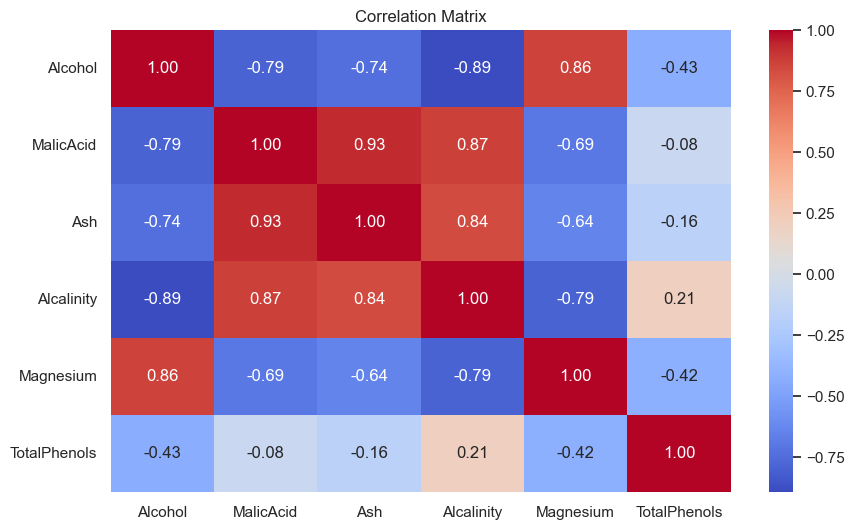

In [5]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 7. Feature Engineering & Scaling

Prepare the features and apply standardization if required.

In [6]:
X = df.copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Standard scaling applied.')

Standard scaling applied.


## 8. Train-Test Split

Divide training and testing sets.

In [7]:
# Unsupervised model - fitting directly on the scaled cohort
print('Skipping split step.')

Skipping split step.


## 9. Model Building

Instantiate and fit the model estimator.

In [8]:
model = PCA(n_components=2)
X_pca = model.fit_transform(X_scaled)
print("Explained Variance Ratio per PC:", model.explained_variance_ratio_)
print("PCs components mapping (eigenvectors):\n", model.components_)

Explained Variance Ratio per PC: [0.71014953 0.21969064]
PCs components mapping (eigenvectors):
 [[-0.45901008  0.44463585  0.4273537   0.46351662 -0.42622369  0.11163882]
 [-0.19680027 -0.2853452  -0.35647575 -0.01703277 -0.24361133  0.83254803]]


## 10. Prediction & 11. Model Evaluation

Check metrics to evaluate model performance.

In [9]:
print('Explained Variance Ratio:', model.explained_variance_ratio_)
print('Cumulative Variance:', np.sum(model.explained_variance_ratio_))

Explained Variance Ratio: [0.71014953 0.21969064]
Cumulative Variance: 0.9298401646655363


## 12. Visualizing Fit & Boundaries

Generate plots showing classification decision zones, regression lines, or clustering segments.

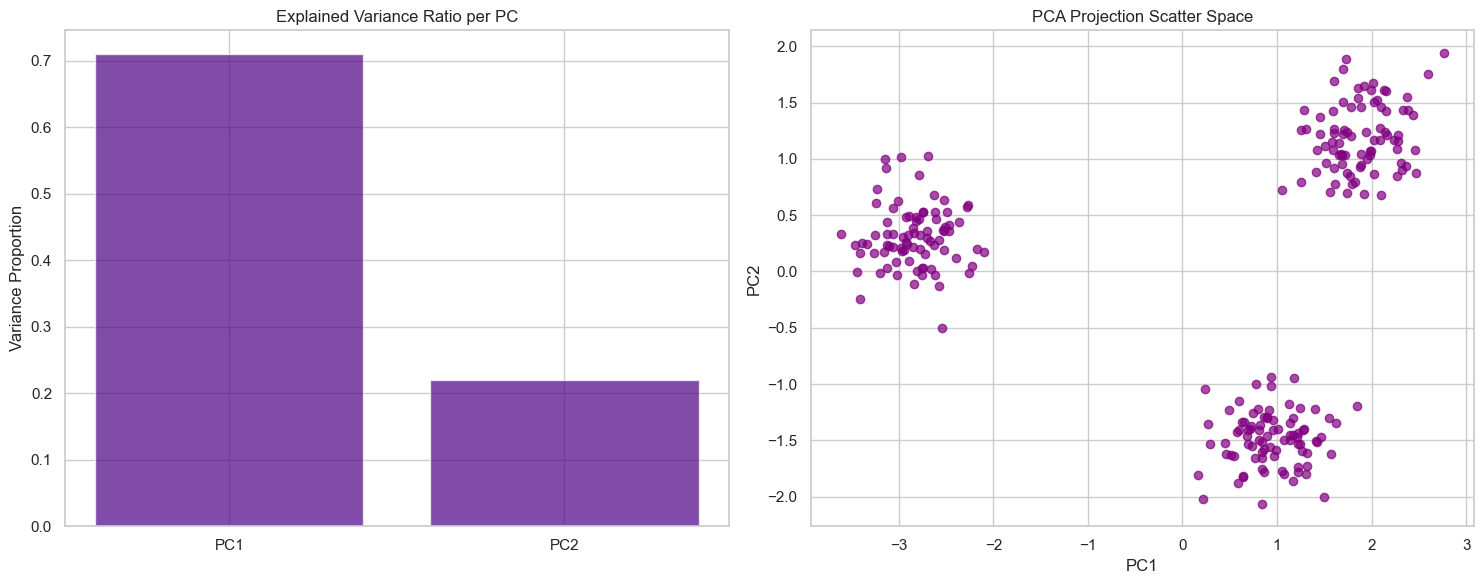

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# Plot 1: Scree Plot
axes[0].bar(['PC1', 'PC2'], model.explained_variance_ratio_, color='indigo', alpha=0.7)
axes[0].set_title("Explained Variance Ratio per PC")
axes[0].set_ylabel("Variance Proportion")

# Plot 2: 2D Projected Scatter
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], color='purple', alpha=0.7)
axes[1].set_title("PCA Projection Scatter Space")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.tight_layout()
plt.show()

## 13. Save and Load Model

Serialize the model to disk via joblib.

In [11]:
joblib.dump(model, 'model.joblib')
loaded = joblib.load('model.joblib')
print('Loaded successfully!')

Loaded successfully!


## 14. Common Mistakes & Best Practices
- Forgetting to apply the fitted scaler to new evaluation data points, leading to prediction errors.
- Overfitting simple models with excessive features or polynomial terms.

## 15. Advantages
- Fast and easy to interpret baseline results.
- Requires minimal parameter tuning compared to deep neural networks.

## 16. Limitations
- Assumes linear or simple spatial patterns that do not always match real-world anomalies.
- Sensitive to noisy labels and extreme outliers.

## 17. Real-World Applications
- Predicting housing market price trends based on space features.
- Classifying credit card transactions as fraudulent vs benign.

## 18. Algorithm-Specific Interview Questions & Answers
**Q1: How does PCA determine the principal directions?**

*A: By finding the eigenvectors of the covariance matrix. The eigenvectors represent directions of variance, and eigenvalues represent the magnitude of variance in those directions.*

**Q2: Why is feature standardization critical before PCA?**

*A: PCA maximizes variance. If one feature is on a larger scale (e.g. salary), PCA will align PC1 along that feature axis simply due to variance magnitude, ignoring other features.*

**Q3: What is the difference between PCA and Autoencoders?**

*A: PCA is a linear transformation, while Autoencoders can capture non-linear relationships using non-linear activation functions in neural network layers.*



## 19. Algorithm-Specific Viva Voce Questions & Answers
**Q1: What does 'explained_variance_ratio_' show?**

*A: The proportion of the dataset's total variance captured by each principal component.*

**Q2: Are principal components correlated?**

*A: No, principal components are orthogonal (perpendicular) to each other, meaning they are completely uncorrelated.*

**Q3: How do you choose the number of PCs?**

*A: By looking at cumulative explained variance (e.g., stopping when the components explain 90% or 95% of the total variance).*



## 20. Practice Exercises
1. **Hyperparameter sweep**: Modify model parameters (such as `max_depth` or neighbor count `K`) and plot the test metric variance curve.
2. **Manual metric calculation**: Compute precision and recall scores manually from the confusion matrix values and verify results using scikit-learn.
3. **Outlier test**: Add an extreme value row to the dataset, re-train, and record the boundary displacement shift.

## 21. Conclusion

In this notebook, we implemented the complete modeling cycle: generating datasets, performing scaling, training the model, evaluating predictions with multiple metrics, saving outputs, and studying typical interview Q&A profiles.